**Experiment 2: Comparison of GPT, T5 and Sequence-to-Sequence Generative Models**

In [9]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu


In [1]:
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 847.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150

In [2]:
!pip install transformers sentencepiece -q

In [3]:
import torch
import torchvision
import transformers

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)

print("All libraries loaded successfully!")

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
Transformers: 5.15.0
All libraries loaded successfully!


In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# GPT-2 Model
gpt_model_name = "distilgpt2"

# Load Tokenizer
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_model_name)

# Load Model
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_model_name)

print("GPT-2 model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 model loaded successfully!


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# T5 Model
t5_model_name = "t5-small"

# Load Tokenizer
t5_tokenizer = AutoTokenizer.from_pretrained(t5_model_name)

# Load Model
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name)

print("T5 model loaded successfully!")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5 model loaded successfully!


In [10]:
# Take user input
topic = input("Sayem, Enter a topic: ")

# Create prompt
gpt_prompt = "Artificial Intelligence is"

# Tokenize input
gpt_inputs = gpt_tokenizer(
    gpt_prompt,
    return_tensors="pt"
)

# Generate text
start_gpt = time.time()

gpt_output = gpt_model.generate(
    **gpt_inputs,
    max_new_tokens=50,
    min_new_tokens=20,
    do_sample=True,
    top_k=50,
    pad_token_id=gpt_tokenizer.eos_token_id
)

gpt_time = time.time() - start_gpt

# Get only newly generated tokens
new_tokens = gpt_output[0][gpt_inputs["input_ids"].shape[1]:]

generated_text = gpt_tokenizer.decode(
    new_tokens,
    skip_special_tokens=True
).strip()

# Display result
print("\n--- GPT-2 Result ---")
print("Model:", "DistilGPT-2")
print("Architecture:", "Autoregressive / Decoder-only")
print("Input:", topic)
print("Generated Output:", generated_text)
print("Inference Time:", round(gpt_time, 3), "seconds")

Sayem, Enter a topic: Artificial Intelligence

--- GPT-2 Result ---
Model: DistilGPT-2
Architecture: Autoregressive / Decoder-only
Input: Artificial Intelligence
Generated Output: a very powerful tool to monitor user behaviour, and it has been a popular idea in several industries since it was introduced in the mid-2000s and is used by many governments around the world as a standard of services.



What is
Inference Time: 2.115 seconds


In [12]:
# T5 text-to-text task
t5_prompt = (
    "summarize: Artificial Intelligence is a field of computer science "
    "that enables machines to perform tasks that normally require "
    "human intelligence."
)

# Tokenize input
t5_inputs = t5_tokenizer(
    t5_prompt,
    return_tensors="pt"
)

# Measure inference time
start_t5 = time.time()

# Generate T5 output
t5_output = t5_model.generate(
    **t5_inputs,
    max_new_tokens=50,
    min_new_tokens=10
)

t5_time = time.time() - start_t5

# Decode generated text
t5_text = t5_tokenizer.decode(
    t5_output[0],
    skip_special_tokens=True
).strip()

# Display result
print("\n--- T5 Result ---")
print("Model:", "T5-small")
print("Architecture:", "Encoder-Decoder / Sequence-to-Sequence")
print("Input:", topic)
print("Generated Output:", t5_text)
print("Inference Time:", round(t5_time, 3), "seconds")


--- T5 Result ---
Model: T5-small
Architecture: Encoder-Decoder / Sequence-to-Sequence
Input: Artificial Intelligence
Generated Output: artificial intelligence is a field of computer science that enables machines to perform tasks that normally require human intelligence.
Inference Time: 1.519 seconds


In [14]:
# Calculate output length
gpt_length = len(generated_text.split())
t5_length = len(t5_text.split())

# Final Comparison
print("\n========== EXPERIMENT 2 COMPARISON ==========")
print("Student: Md Abu Sayem")
print("Student ID: 25/SET/MTCE/014")
print("Input Topic:", topic)

print("\n--- GPT-2 ---")
print("Model: DistilGPT-2")
print("Architecture: Autoregressive / Decoder-only")
print("Output Length:", gpt_length, "words")
print("Inference Time:", round(gpt_time, 3), "seconds")

print("\n--- T5 ---")
print("Model: T5-small")
print("Architecture: Encoder-Decoder / Sequence-to-Sequence")
print("Output Length:", t5_length, "words")
print("Inference Time:", round(t5_time, 3), "seconds")

print("\n--- Comparison ---")
print("GPT-2 Output Length:", gpt_length, "words")
print("T5 Output Length:", t5_length, "words")
print("GPT-2 Inference Time:", round(gpt_time, 3), "seconds")
print("T5 Inference Time:", round(t5_time, 3), "seconds")

print("\nStudent ID: 25/SET/MTCE/014")


========== EXPERIMENT 2 COMPARISON ==========
Student: Md Abu Sayem
Student ID: 25/SET/MTCE/014
Input Topic: Artificial Intelligence

--- GPT-2 ---
Model: DistilGPT-2
Architecture: Autoregressive / Decoder-only
Output Length: 41 words
Inference Time: 2.115 seconds

--- T5 ---
Model: T5-small
Architecture: Encoder-Decoder / Sequence-to-Sequence
Output Length: 19 words
Inference Time: 1.519 seconds

--- Comparison ---
GPT-2 Output Length: 41 words
T5 Output Length: 19 words
GPT-2 Inference Time: 2.115 seconds
T5 Inference Time: 1.519 seconds

Student ID: 25/SET/MTCE/014


In [16]:
import matplotlib.pyplot as plt

# Model names
models = ["DistilGPT-2", "T5-small"]

# Values
inference_times = [gpt_time, t5_time]
output_lengths = [gpt_length, t5_length]

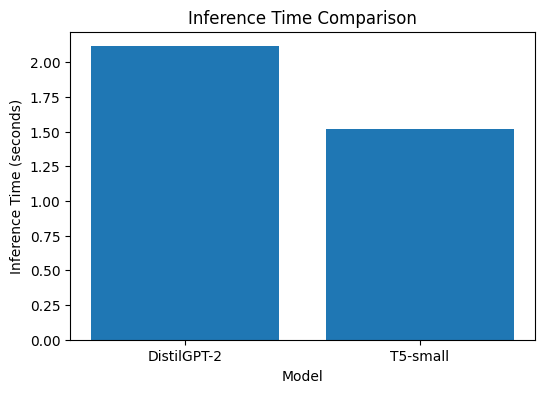

In [17]:
# Graph 1: Inference Time

plt.figure(figsize=(6, 4))

plt.bar(models, inference_times)

plt.title("Inference Time Comparison")
plt.xlabel("Model")
plt.ylabel("Inference Time (seconds)")

plt.show()

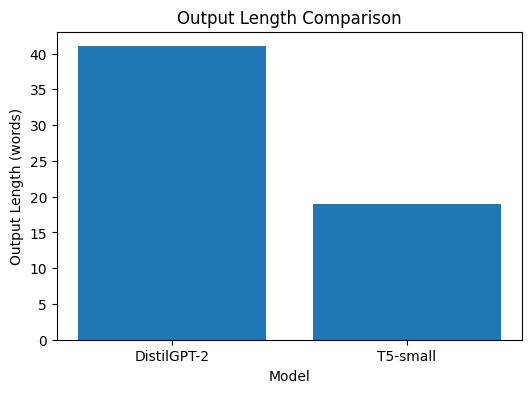

In [18]:
# Graph 2: Output Length

plt.figure(figsize=(6, 4))

plt.bar(models, output_lengths)

plt.title("Output Length Comparison")
plt.xlabel("Model")
plt.ylabel("Output Length (words)")

plt.show()